In [24]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

plt.style.use("default")  

In [26]:
dataset_2025= pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2025.csv")
dataset_2026= pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2026.csv")
df = pd.concat([dataset_2025, dataset_2026])

In [27]:
df.head()


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [28]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [29]:
df['Arrival_Date'] 
pd.to_datetime(df['Arrival_Date'], errors='coerce')
data = df.sort_values('Arrival_Date')
print(df['Arrival_Date'].min(), df['Arrival_Date'].max())

2025-01-01 2026-01-26


In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 164959
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [31]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [32]:
df['Modal_Price'].describe()

count    5.984442e+06
mean     4.481359e+03
std      6.596095e+03
min      5.000000e-02
25%      2.040000e+03
50%      3.400000e+03
75%      5.500000e+03
max      4.000000e+06
Name: Modal_Price, dtype: float64

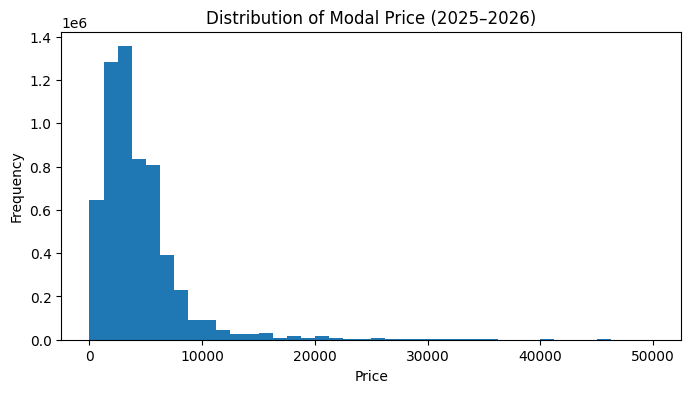

In [33]:
plt.figure(figsize=(8,4))
filtered_data = data[data['Modal_Price'] < 50000]
plt.hist(filtered_data['Modal_Price'], bins=40)
plt.title("Distribution of Modal Price (2025–2026)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [34]:
df['Modal_Price'].dtype

dtype('float64')

In [35]:
print(f"Minimum Price: {data['Modal_Price'].min()}")
print(f"Maximum Price: {data['Modal_Price'].max()}")
print(f"Mean Price: {data['Modal_Price'].mean():.2f}") # :.2f rounds to 2 decimal places
print(f"First 20 Unique Values: {data['Modal_Price'].unique()[:20]}")

print("\nTop 10 Value Counts:")
print(data['Modal_Price'].value_counts().head(10))

Minimum Price: 0.05
Maximum Price: 4000000.0
Mean Price: 4481.36
First 20 Unique Values: [ 3500.    1100.    1500.    2600.    1000.    9500.   15500.   12500.
 15000.   11500.    1000.05  4000.    2500.     700.    2200.    1667.5
   900.    2000.    3700.    3800.  ]

Top 10 Value Counts:
Modal_Price
3000.0    312798
4000.0    303411
5000.0    221599
2000.0    211296
6000.0    201494
2500.0    200514
3500.0    170500
7000.0    120404
1500.0    118197
4500.0    110319
Name: count, dtype: int64


In [36]:
top_crops = data['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [37]:
df=data.copy()

In [38]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 0


In [39]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5984442, 11)


In [40]:
df['Year']=df['Arrival_Date'].dt.year
print(df[['Arrival_Date','Year']].head())

      Arrival_Date  Year
0       2025-01-01  2025
10231   2025-01-01  2025
10232   2025-01-01  2025
10233   2025-01-01  2025
10234   2025-01-01  2025


In [41]:
yearly_avg = df.groupby('Year')['Modal_Price'].mean()
print(yearly_avg)

Year
2025    4479.058924
2026    4568.598726
Name: Modal_Price, dtype: float64


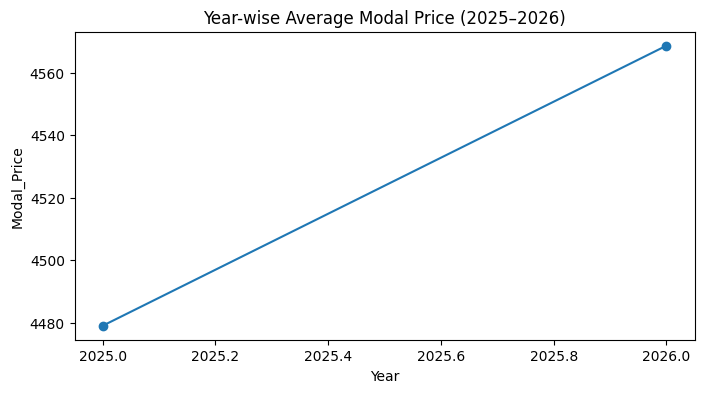

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Year-wise Average Modal Price (2025–2026)")
plt.xlabel("Year")
plt.ylabel("Modal_Price")
plt.show()

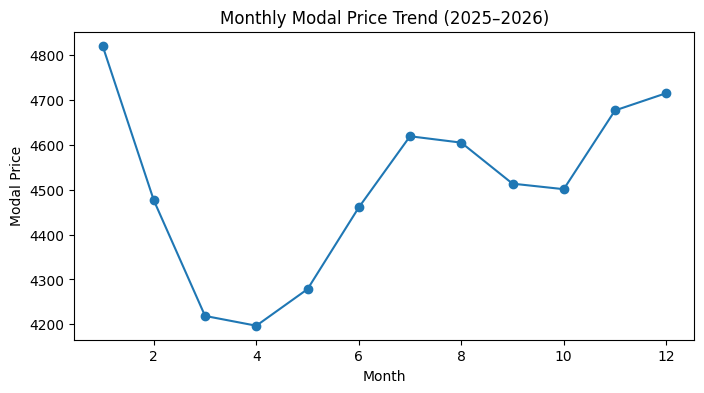

In [43]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Modal_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Modal Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Modal Price")
plt.show()

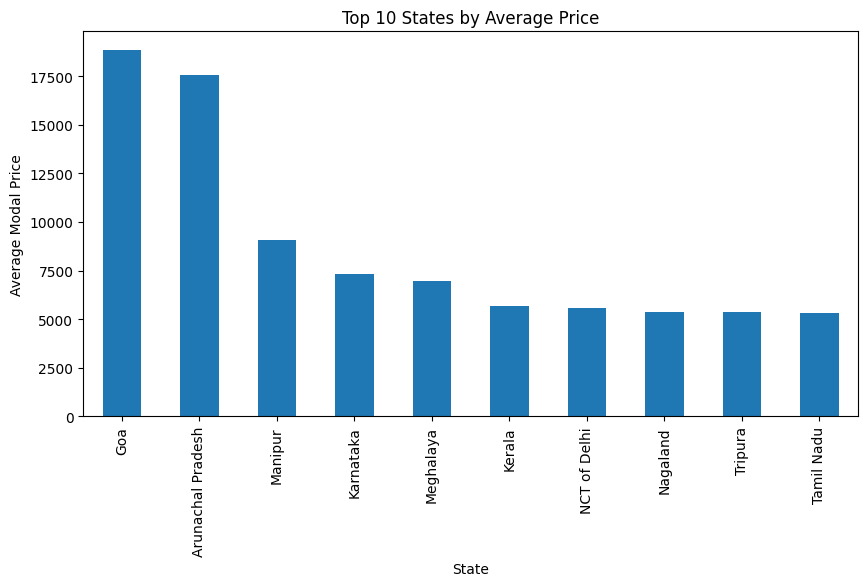

In [44]:
state_avg = df.groupby('State')['Modal_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Modal Price")
plt.show()

In [45]:
df['price_spread'] = df['Max_Price'] - df['Min_Price']
df['price_spread'].describe()

count    5.984442e+06
mean     6.969485e+02
std      2.245846e+03
min     -6.400000e+04
25%      1.000000e+02
50%      4.000000e+02
75%      7.100000e+02
max      8.484000e+05
Name: price_spread, dtype: float64

In [46]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

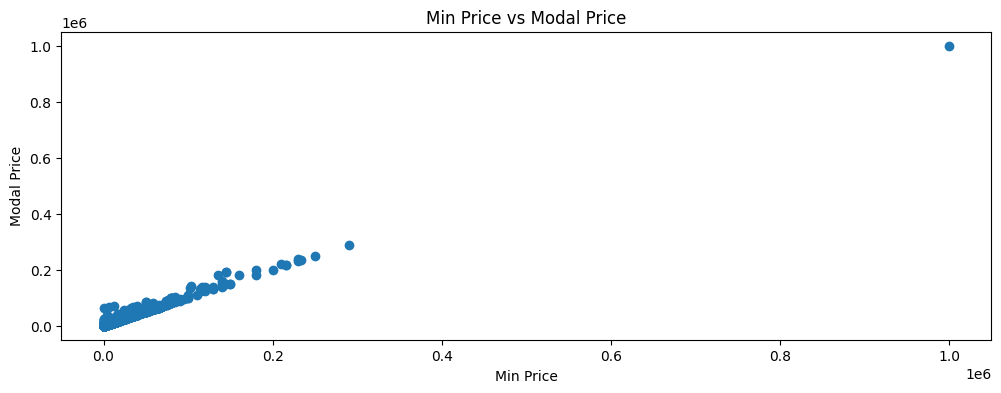

In [48]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.scatter(sample['Min_Price'], sample['Modal_Price'])
plt.xlabel("Min Price")
plt.ylabel("Modal Price")
plt.title("Min Price vs Modal Price")
plt.show()

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


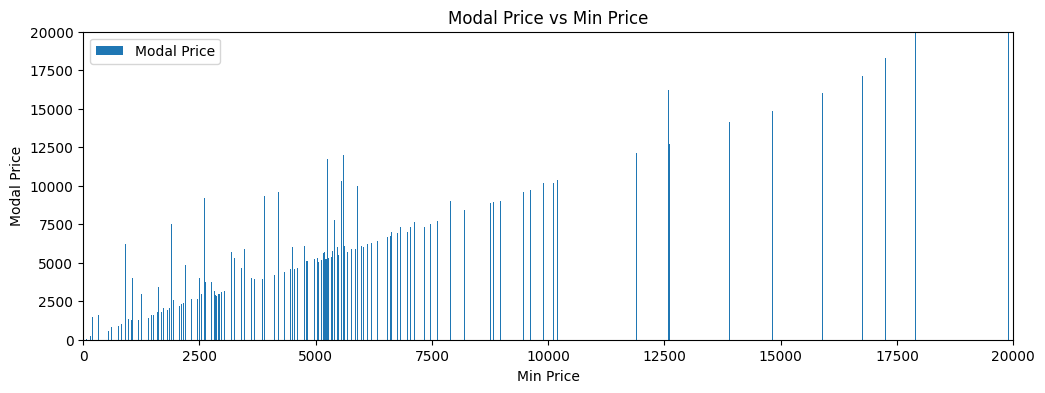

In [49]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.bar(sample['Min_Price'], sample['Modal_Price'], label='Modal Price')
plt.xlim(0, 20000)
plt.ylim(0,20000)
plt.xlabel("Min Price")
plt.ylabel("Modal Price")
plt.title("Modal Price vs Min Price")

plt.legend()
plt.show()

In [50]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
Year              0
month             0
price_spread      0
dtype: int64

In [51]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code', 'Year', 'month', 'price_spread'],
      dtype='str')

In [52]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Clean the data
df_final = df.dropna(subset=['Modal_Price']).copy()

# 2. Use LabelEncoder for all text columns
# We save the encoders in a dictionary so we can use them in Gradio later
encoders = {}
categorical_cols = ['State', 'District', 'Market', 'Commodity', 'Variety']

for col in categorical_cols:
    le = LabelEncoder()
    # Convert to string to avoid errors with mixed types/NaNs
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    encoders[col] = le 

# 3. Define X and y (Using only the columns you want for prediction)
X = df_final[categorical_cols + ['Min_Price', 'Max_Price']]
y = df_final['Modal_Price']

# 4. Fit the model
from sklearn.linear_model import LinearRegression
model = LinearRegression(positive=True)
model.fit(X, y)

print("Model trained successfully with Label Encoding!")

Model trained successfully with Label Encoding!


In [53]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

In [55]:
from sklearn.linear_model import LinearRegression
df_encoded = pd.get_dummies(df_final,columns=['State'])
y = df_encoded['Modal_Price']
X = df_encoded.drop('Modal_Price', axis=1)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
y_pred = model.predict(X_test)
y_pred

array([5232.80341084, 3801.798179  ,  582.87370504, ..., 5644.46246566,
       4129.77872731, 2302.80534104], shape=(1196889,))

In [57]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.9888771948656228


In [58]:
print("R2 score: ",r2_score(y_test, y_pred))

R2 score:  0.9888771948656228


In [59]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
1213038,4800.0,5232.803411
5782993,3788.0,3801.798179
4050767,500.0,582.873705
5246691,4200.0,3831.796405
2300690,5000.0,5163.471459


In [60]:
import pandas as pd
import numpy as np

In [61]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import gradio as gr
import numpy as np

In [63]:
import gradio as gr
import numpy as np

# 1. The Prediction Logic
def predict_modal_price(state, district, market, commodity, variety, max_price, min_price):
    try:
        # Match the exact column order from your training: Categorical + Max + Modal
        encoded_values = []
        inputs_list = [state, district, market, commodity, variety]
        
        for i, col in enumerate(categorical_cols):
            le = encoders[col]
            # Transform text selection back to the number the model knows
            encoded_values.append(le.transform([str(inputs_list[i])])[0])
        
        # Combine categorical numbers with the two price inputs
        final_features = encoded_values + [max_price, min_price]
        
        # Predict using the model
        prediction = model.predict([final_features])[0]
        
        # Return formatted HTML for a professional look
        return f"""
        <div style='text-align: center; background: #f0f9ff; padding: 20px; border-radius: 10px; border: 2px solid #bae6fd;'>
            <p style='color: #0369a1; font-size: 16px; margin: 0;'>Estimated Modal Price</p>
            <h1 style='color: #0284c7; font-size: 36px; margin: 10px 0;'>₹{round(prediction, 2)}</h1>
        </div>
        """
    except Exception as e:
        return f"<p style='color: red;'>Error: {str(e)}</p>"

# 2. The Professional Interface
with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky"), title="ModalPrice AI") as demo:
    gr.Markdown("# 🛰️ MODAL PRICE PREDICTION")
    gr.Markdown("Predict the modal price based on market location and product type.")
    
    with gr.Row():
        # Input Section
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### 📍 Location & Product")
            state = gr.Dropdown(choices=list(encoders['State'].classes_), label="State")
            dist = gr.Dropdown(choices=list(encoders['District'].classes_), label="District")
            mkt = gr.Dropdown(choices=list(encoders['Market'].classes_), label="Market")
            comm = gr.Dropdown(choices=list(encoders['Commodity'].classes_), label="Commodity")
            var = gr.Dropdown(choices=list(encoders['Variety'].classes_), label="Variety")
            
            gr.Markdown("### 💰 Known Price Points")
            max_p = gr.Number(label="Max Price (Upper Bound)", value=0)
            min_p = gr.Number(label="Min Price (Lower Bound)", value=0)
            
            submit_btn = gr.Button("GENERATE PREDICTED MODAL PRICE", variant="primary")

        # Output Section
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Prediction Result")
            output_html = gr.HTML("<p style='text-align: center; color: gray;'>Fill inputs and click generate...</p>")
            
            # Adding a helpful tip box
            gr.Info("Note: This model uses Linear Regression based on historical market trends.")

    # Link button to function
    submit_btn.click(
        fn=predict_modal_price,
        inputs=[state, dist, mkt, comm, var, max_p, min_p],
        outputs=output_html
    )

demo.launch()

C:\Users\pc\AppData\Local\Temp\ipykernel_23160\2490010311.py:33: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky"), title="ModalPrice AI") as demo:


Note: This model uses Linear Regression based on historical market trends.
* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [64]:
import pickle 
with open('modal_price.pkl', 'wb') as f:
    pickle.dump(model,f)

In [65]:
import pickle

# Access each encoder from your 'encoders' dictionary and save it separately
pickle.dump(encoders['State'], open('le_state.pkl', 'wb'))
pickle.dump(encoders['District'], open('le_district.pkl', 'wb'))
pickle.dump(encoders['Commodity'], open('le_commodity.pkl', 'wb'))

print("Encoders saved correctly!")

Encoders saved correctly!
